In [ ]:
import symqups as sq
import numpy as np
from time import perf_counter
from IPython.display import display

a_lst = [sq.alpha(i) for i in range(10)]
ad_lst = [sq.alphaD(i) for i in range(10)]
aOp_lst = [sq.annihilateOp(i) for i in range(10)]
adOp_lst = [sq.createOp(i) for i in range(10)]

N_samples = 100

def benchmark_1():
    # One subsystem, increase polynomial order
    
    max_n_var = 10
    
    a = a_lst[0]
    ad = ad_lst[0]
    aOp = aOp_lst[0]
    adOp = adOp_lst[0]
    
    out = []
    for n_var in range(max_n_var+1):
        dur = 0
        for _ in range(N_samples):
            poly = sq.get_random_poly([a,ad], 
                                      min_pow=n_var, 
                                      max_pow=n_var, 
                                      n_terms=1)
            t_start = perf_counter()
            sq.Star(poly, sq.W)
            dur += perf_counter()-t_start
        out.append([n_var, dur/N_samples])
    np.savetxt(f"benchmark-data/benchmark_1_star.txt", out)
    
    out = []
    for n_var in range(max_n_var+1):
        dur = 0
        for _ in range(N_samples):
            poly = sq.get_random_poly([aOp,adOp], 
                                      min_pow=n_var, 
                                      max_pow=n_var, 
                                      n_terms=1)
            t_start = perf_counter()
            sq.HattedStar(poly, sq.rho)
            dur += perf_counter()-t_start
        out.append([n_var, dur/N_samples])
    np.savetxt(f"benchmark-data/benchmark_1_hattedstar.txt", out)

    out = []
    for n_var in range(max_n_var+1):
        dur = 0
        for _ in range(N_samples):
            poly = sq.get_random_poly([a,ad], 
                                      min_pow=n_var, 
                                      max_pow=n_var, 
                                      n_terms=1)
            t_start = perf_counter()
            sq.iCGTransform(poly*sq.W)
            dur += perf_counter()-t_start
        out.append([n_var, dur/N_samples])
    np.savetxt(f"benchmark-data/benchmark_1_icgtransform.txt", out)

def benchmark_2():
    # Increase subsystem, fixed polynomial order
    
    poly_order = 6
    max_n_sub = 10
    
    out = []
    for n_sub in range(1, max_n_sub+1):
        dur = 0
        for _ in range(N_samples):      
            poly = sq.get_random_poly(a_lst[:n_sub]+ad_lst[:n_sub], 
                                        min_pow=poly_order, 
                                        max_pow=poly_order, 
                                        n_terms=1)
            t_start = perf_counter()
            sq.Star(poly, sq.W)
            dur += perf_counter()-t_start
        out.append([n_sub, dur/N_samples])
    np.savetxt(f"benchmark-data/benchmark_2_star.txt", out) 
    
    out = []
    for n_sub in range(1, max_n_sub+1):
        dur = 0
        for _ in range(N_samples):      
            poly = sq.get_random_poly(aOp_lst[:n_sub]+adOp_lst[:n_sub], 
                                        min_pow=poly_order, 
                                        max_pow=poly_order, 
                                        n_terms=1)
            t_start = perf_counter()
            sq.HattedStar(poly, sq.rho)
            dur += perf_counter()-t_start
        out.append([n_sub, dur/N_samples])
    np.savetxt(f"benchmark-data/benchmark_2_hattedstar.txt", out)
    
    out = []
    for n_sub in range(1, max_n_sub+1):
        dur = 0
        for _ in range(N_samples):
            poly = sq.get_random_poly(a_lst[:n_sub]+ad_lst[:n_sub], 
                                        min_pow=poly_order, 
                                        max_pow=poly_order, 
                                        n_terms=1)
            t_start = perf_counter()
            sq.iCGTransform(poly*sq.W)
            dur += perf_counter()-t_start
        out.append([n_sub, dur/N_samples])
    np.savetxt(f"benchmark-data/benchmark_2_icgtransform.txt", out) 
         
# benchmark_1()
# benchmark_2()

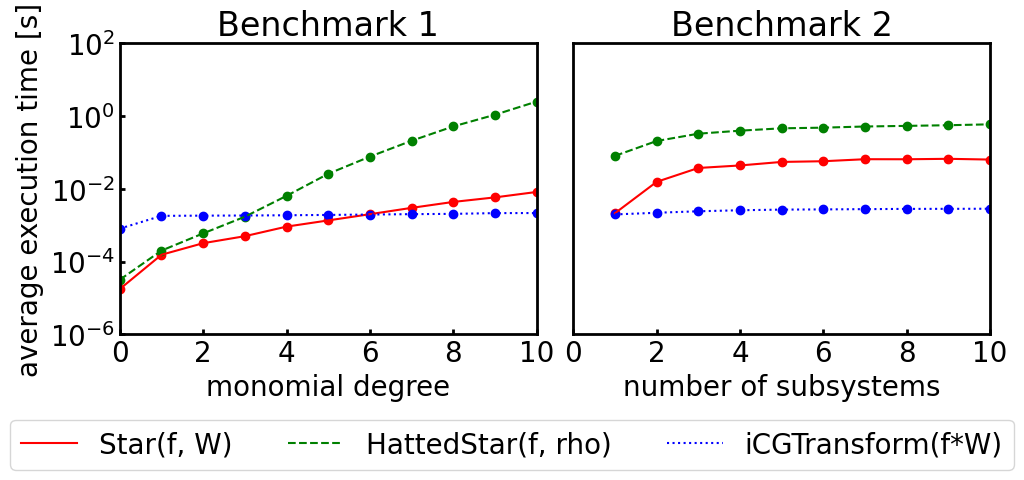

In [44]:
import matplotlib.pyplot as plt
plt.rcParams["axes.linewidth"] = 2
plt.rcParams["font.size"] = 20

fig, axes = plt.subplots(1,2, constrained_layout=True, figsize = (10, 4))

for i, sss in enumerate(["star", "hattedstar", "icgtransform"]):
    
    n_var, dur_avg = np.loadtxt(f"benchmark-data/benchmark_1_{sss}.txt", unpack=True)
    n_var = n_var.astype(int)
    ax = axes[0]
    ax.plot(n_var,
            dur_avg,
            c = ["r", "g", "b", "k"][i],
            ls = ["-", "--", ":", "-."][i],
            label = ["Star(f, W)",
                     "HattedStar(f, rho)",
                     "iCGTransform(f*W)"][i])
    ax.scatter(n_var,
               dur_avg,
               color = ["r","g","b","k"][i])
    ax.set_yscale("log")
    ax.set_ylim(1e-6, 1e2)
    ax.tick_params(axis="both", which="both", direction='in', width=2)
    ax.set_ylabel("average execution time [s]")
    ax.set_xticks([0,2,4,6,8,10])
    ax.set_xlabel("monomial degree")
    ax.set_title("Benchmark 1")
    ax.set_xlim(0, 10)

    n_sub, dur_avg = np.loadtxt(f"benchmark-data/benchmark_2_{sss}.txt", unpack=True)
    n_sub = n_sub.astype(int)
    ax = axes[1]
    ax.plot(n_sub,
            dur_avg,
            c = ["r", "g", "b", "k"][i],
            ls = ["-", "--", ":", "-."][i])
    ax.scatter(n_sub,
               dur_avg,
               color = ["r","g","b","k"][i])
    ax.set_yscale("log")
    ax.set_xlim(0, 10)
    ax.set_xlabel("number of subsystems")
    ax.set_xticks([0,2,4,6,8,10])
    ax.set_ylim(1e-6, 1e2)
    ax.set_yticks([])
    ax.tick_params(axis="both", which="both", direction='in', width=2)
    ax.set_title("Benchmark 2")
    
fig.legend(ncols=3, loc="center", bbox_to_anchor=(0.5, -0.1), frameon=True, fontsize=20)

plt.savefig("benchmark.pdf", dpi=600, bbox_inches="tight")